<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangChain_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai langchain-community langchain-chroma langchain-text-splitters langsmith

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2

## Agent:
  - имаме ai model, който приема съобщения и връща съобщения. AI Models & auto regresivnite modeli са добри в да разбират и да произвеждат текст. В последствие ние ги опитомяваме на база на текста който произвеждат те да могат да си поискат изпълнението на определн инструмент.
# Model
# Tools:
  - като функция е приема аргументи и връща някакъв резултат
  - хубаво е да връща текст, заради AI Model защото модела работи предимно с текст
# Loader
  - да зареди някакво съдържание, само че зареждането на това съдържание се случва с цел популирането на някаква спомагателна система. Идеята на loaders е че зареждат документи. Тези документи дали ще се намират в нашата файлова система, в гитхъб, notion няма значение, за интеграции с всякакви външни системи. Разчитаме на интерфейсите на loaders да извлекат текстово съдържание, имаме loaders най-различни с различна цел, някой са специализирани, приличат си по своята насоченост. След като сме заредили документите, трябва да ги разпачосаме - да го разделим на чънкове и тук идва сплитъра
# Splitter:
  - има най-различни стратегии за сплитване, на първо място е RecurisiveCharacterTextSplitter - той е за случаите, в които работим с естествен текст. RecurisiveCharacterTextSplitter Чисто йерархично ще се опита да раздели текста, да запази параграфите, ще се опита да запази структурата на изреченията, няма да среже думите.
  - Length-based: примитивен подход, 1000 символа един чънк и с овърлап само че не е добър защото остават срязани думи в началото и в края и се губи смисъла
  - Document structure-based: той е за md files, разделя го структурно , така ще запазим целостта на въпроса и на отговора от md file и те ще вървят в complect -> с помощта на Split markdown - text splitter integration. Сплитва за да получим чънкове, които ще пазим във векторна база.

  **- Използваме да заредим документи !!!**
# VectorStore:
  - векторната база ни дава възможност да запишем множество документи, като всеки един от тези документи се ембедва. Тоест използваме специализиран вектор модел чрез който ние да оценим семантичното значение и да го представим като вектор т.е като списък от числа. Съответно ролята на векторната база е да може да организира всички тези вектори по интелигентен и оптимален начин и да може бързо да отговаря на query. Когато ние запишем някакво query или ai прецени че иска да търси някаква информация - ще бъде съставен нов ембединг вектор за quer-ито и векторната база трябва да може да намери чисто смислово тези вектори, които най-много се доближават до query-то
    - имаме In-memory
    - chroma
    - mongoDb
    - pinecone
** # Retriever: -> at inference time **
  - дават възможност на нашият агент да търси/извлича информация от някакъв източник - дали ще взимаме от wikipedia, arxiv, векторна база - няма значение. Въпроса е че reatreavera също зарежда текст но в контекста на нашият агент.
# Middleware:
# Checkpointer
# Store
# Graph + Node

In [ ]:
# Agent: имаме ai model, който приема съобщения и връща съобщения. AI Models & auto regresivnite modeli са добри в да разбират и да произвеждат текст. В последствие ние ги опитомяваме на база на текста който произвеждат те да могат да си поискат изпълнението на определн инструмент.
# Model
# Tools
# Loader
# Splitter
# Retriever
# Middleware
# Checkpointer
# Store
# Graph + Node

In [2]:
import os
import json

from IPython.display import Image
from google.colab import userdata
from langchain.agents import AgentState, create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain.agents.middleware.types import after_model, before_model
from langchain_core.messages import BaseMessage
from langchain_community.document_loaders import TextLoader
from langchain_core.tools import create_retriever_tool
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_openai import ChatOpenAI
from langgraph.runtime import Runtime
from langchain_chroma import Chroma
from typing import List

/tmp/ipykernel_4099/3922627870.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


In [3]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = "demo-colab-project"
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [4]:
def print_conversation(messages: List[BaseMessage]) -> None:
    for message in messages:
        message.pretty_print()

In [5]:
openai_api_key = userdata.get('OPENAI_API_KEY')
openai_model = ChatOpenAI(model = "gpt-5.6-luna", api_key = openai_api_key, use_responses_api = True)

In [6]:
chroma = Chroma(collection_name = "faq", persist_directory="/content/chroma")

In [ ]:
# agent = create_agent(
#     model = openai_model,
#     tools = [],
#     system_prompt = "You are a helpful customer support agent.",
#     debug = True
# )

за да се обърнем към агента трябва да извикаме **invoke** и очакваме да подадем някакъв обект / речник.
Стартирайки обръщението към нашият агент трябва да подготвим дефолтен state и agent state е обект в който имаме списък от съобщения и различните съобщения могат да бъдат AIMessage, ToolCallMessage, HumanMessage

- AIMessage е директният отговор, който ai ни е върнал

- **Всяко едно обръщение към agent.Invoke() е една отделна независима сесия, независим от предишният разговор.**

In [ ]:
# exploration_response = agent.invoke(
#     input =
#     {
#         "messages": [
#             HumanMessage("Hello! My name is Nikol, nice to meet you!")
#         ]
#     }
# )

In [ ]:
# print_conversation(exploration_response['messages'])

*   зареждаме файла
*   сплитваме го
* слагаме го във векторна база
* след това да пострим един retreaver, който по време на inference чрез съответен инструмент ще дадем възможност на модела да търси информация във нашият вътрешен knowledge base
<hr/>

**това е необходимо за нашата RAG идея**

**RAG**(Retrieval Augmented Generation) - зареждаме документите, вкарваме ги във векторната база и построяваме retreaver, който в същото време е инструмент чрез който агента може да получи тази информация на база на query-тата, които ще изпълнява.
<hr/>

**CAG** (Cache Augmented Generation) - е идеята, при която зареждаме съдържанието на този файл и директно го вкарваме в системният промпт, директно обогатяваме контекста на нашият агент с цялата налична информация. И тогава той ще може да я съобрази, тогава той ще може да бъде helpfull personal or customer support assistant.
  - проблема при CAG е когато документа ни стане много голям или имаме много различни документи, с различни особености няма как да влезнат в системният промпт.

In [7]:
text_loader = TextLoader(file_path="/content/FAQ.md")
splitter = MarkdownHeaderTextSplitter(headers_to_split_on = [('##', 'question')], strip_headers=False)

documents = text_loader.load()

In [8]:
documents = text_loader.load()

chunks_to_embed = []
for document in documents:
    chunks_to_embed.extend(splitter.split_text(document.page_content))

In [9]:
chunks_to_embed

[Document(metadata={'question': 'Q1. What is the warranty?'}, page_content='# Company FAQ  \n## Q1. What is the warranty?  \nThe warranty period is **24 months for individuals** and **12 months for legal entities**.  \nThe warranty does not cover mechanical damage, liquid damage, improper use, or unauthorized repairs.  \n---'),
 Document(metadata={'question': 'Q2. How do I make a warranty claim?'}, page_content='## Q2. How do I make a warranty claim?  \nYou can submit a warranty claim through the form on our website or by contacting customer support.  \nPlease provide:  \n- your order number;\n- a short description of the problem;\n- photos of the product, if relevant.  \nOur service department will review the request and respond within **2 business days**.  \n---'),
 Document(metadata={'question': 'Q3. How long does a repair take?'}, page_content='## Q3. How long does a repair take?  \nWarranty repairs may take up to **30 calendar days**.  \nIf a required spare part is unavailable, cu

In [10]:
chroma.add_documents(chunks_to_embed)

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:03<00:00, 23.8MiB/s]


['0b1538f8-b017-43cf-8704-8386f49d5921',
 '414aea70-8dcd-4ba1-9098-af6df34c000f',
 '88b431d7-6981-42ca-80d7-f091a57f8650',
 '710a6061-5467-4be7-a2d1-49d8a8c5bfba',
 '30b73460-afbe-4009-9015-6ffb99a91222',
 'fc0c6b81-8f29-4ed3-9642-b1fa06c00aa9',
 '8d6a4d9b-4a42-46a7-a43c-b70a51848072',
 '331b25ee-ce25-47ea-b7b6-75b78c86b324',
 '9c3d9781-8120-4ad4-aba8-c83a3baaf374',
 '710befe5-5135-45dc-8d65-25c9bba87e75',
 '4609c40f-6990-4112-bcd6-911ed7f38e00',
 'c5dc62e3-12bc-4c81-bb04-7fdf34a4a243']

In [11]:
## @tool
# всеки един инструмент е json обект, който описва името на инструментите, аргументите и дава описание за самият инструмент заедно с описание за всеки един от аргументите
# def search_knowledgebase(query: str) -> str:
#     """
#     Call this tool to search the internal knowledgebase using natural language query.
#     """

#     results = chroma.similarity_search(query, k = 3)

#     return "\n\n----\n\n".join(d.page_content for d in results)
# What now?
# 1. We can implement a custom tool that accepts query, searches withing the VDB, and returns results
# 2. Transform the VDB into Retriever and than Tool

chroma_retriever = chroma.as_retriever(search_kwargs={"k":3}) # построяваме retreavara и имайки го после построяваме инструмент
search_knowledgebase = create_retriever_tool(chroma_retriever, 'search_knowledgabase', "Call this tool to search the internal knowledgebase using natural language query.", document_separator="\n\n----\n\n")

In [12]:
@tool
def my_orders() -> str:
    """
    Call this tool to retrieve all orders of the customer.
    """

    orders = [
        {"id": 13, "status": "pending"},
        {"id": 25, "status": "delivered"}
    ]

    return json.dumps(orders)

@tool
def lookup_order_details(id: int) -> str:
    """
    Call this tool to lookup additional information about a given order by its id.
    """
    details = {
        13: {
            "price": 3.14,
            "vat": 1.06,
            "products": "whole milk"
        },
        25: {
            "price": 17.89,
            "vat": 3.08,
            "products": "keyboard & mouse"
        },
    }

    result = details.get(id)
    if result is None:
        return "An order with this id was not found"

    return json.dumps(result)

In [13]:
my_orders.invoke(input="")

'[{"id": 13, "status": "pending"}, {"id": 25, "status": "delivered"}]'

In [ ]:
# system_prompt_fragments = ["You are a helpful customer support agent."]
# system_prompt_fragments.extend(d.page_content for d in documents)
# system_prompt_fragments

In [14]:
@before_model
def before_model_func(state: AgentState, runtime: Runtime) -> None:
    print("Event: before_model")

@after_model
def after_model_func(state: AgentState, runtime: Runtime) -> None:
    print("Event: after_model")
    print(f"Usage: {state['messages'][-1].usage_metadata}")

In [15]:
agent = create_agent(
    model = openai_model,
    tools = [search_knowledgebase, my_orders, lookup_order_details],
    middleware = [before_model_func, after_model_func],
    system_prompt = "You are a helpful customer support agent.", # previously we did it with CAG approach - "\n\n\n".join(system_prompt_fragments), # cag
    debug = True
)

агента е конкретна реализация на граф. граф построен от бибилотеката LangGraph. LangGraph дава основата върху която стъпва LangChain.

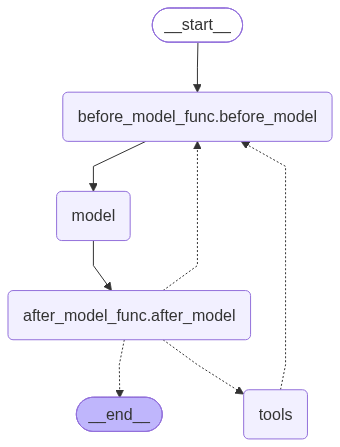

In [16]:
display(Image(agent.get_graph().draw_mermaid_png(), format="png"))

In [17]:
delivery_response = agent.invoke(
    input =
    {
        "messages": [
            HumanMessage("How long should I wait for a standard delivery? Do you offer an express option?")
        ]
    }
)

[values] {'messages': [HumanMessage(content='How long should I wait for a standard delivery? Do you offer an express option?', additional_kwargs={}, response_metadata={}, id='c47fa2e4-728a-4c4c-a721-3f4b9f45eeee')]}
Event: before_model
[updates] {'before_model_func.before_model': None}
[updates] {'model': {'messages': [AIMessage(content=[{'id': 'rs_02f39e41c9f09495006a8d41d9178c87d288ad66b8ccad3422', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqjUHZNZ5_fGPnlr37_PmY4i1IPX6BJQ-3a9gSwqDJojsncGwf1TrLf1f5Jn_YFjPxXl_pbXqTm6hb7NvClGs03BOqNUs7feyXtdJnWyXrtK1j57LPdqVAtiPelzlMur1KwxvTWRTXTYTOnb1YSbUORlw5MvoFTEsyCM_qYTMVOd4iPEvTaZ6Oi5nZw4RO7JJmxKVbGPq1kJzkeapig5Q0n0HNrnMVcNvHGJjpm39wNt-nH2qgZyZrOjw1uuIlnghs-eLgEB6-chnBvloCifKUnZ2g1htvIfJ0tX2vX6JT39QcdGRUXsV1ZIgjmmWMX5ebLkvV5I7va17f-N-K5RgyGj_iLeUkDhTErZXDyyLSnwFWMCg1ZVu0c9A-NKw6RMtA67q3FdPvtQORqyJTqbrDjM4Il8pEN9Dajs_gb9MQlbptddtaWw4QCtorLkSvW0gdSL2k9PKlx3eSeqRZP_TkZeNyeN03f8RpnemtrimWVC9RHjsaLvP0bumWXb61e_-Li42

In [18]:
print_conversation(delivery_response['messages'])

================================ Human Message =================================

How long should I wait for a standard delivery? Do you offer an express option?
================================== Ai Message ==================================

[{'id': 'rs_02f39e41c9f09495006a8d41d9178c87d288ad66b8ccad3422', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqjUHZNZ5_fGPnlr37_PmY4i1IPX6BJQ-3a9gSwqDJojsncGwf1TrLf1f5Jn_YFjPxXl_pbXqTm6hb7NvClGs03BOqNUs7feyXtdJnWyXrtK1j57LPdqVAtiPelzlMur1KwxvTWRTXTYTOnb1YSbUORlw5MvoFTEsyCM_qYTMVOd4iPEvTaZ6Oi5nZw4RO7JJmxKVbGPq1kJzkeapig5Q0n0HNrnMVcNvHGJjpm39wNt-nH2qgZyZrOjw1uuIlnghs-eLgEB6-chnBvloCifKUnZ2g1htvIfJ0tX2vX6JT39QcdGRUXsV1ZIgjmmWMX5ebLkvV5I7va17f-N-K5RgyGj_iLeUkDhTErZXDyyLSnwFWMCg1ZVu0c9A-NKw6RMtA67q3FdPvtQORqyJTqbrDjM4Il8pEN9Dajs_gb9MQlbptddtaWw4QCtorLkSvW0gdSL2k9PKlx3eSeqRZP_TkZeNyeN03f8RpnemtrimWVC9RHjsaLvP0bumWXb61e_-Li42cLcROAOsPTKLJ5pjsdhZ2mwyXxZB28Yp9uHJmcthmNVUGMf6AWAP0xgh9MzFuHsgz7kMbCQDnT84qoPwVPDj3MRB-A4k1-8

In [19]:
my_orders_response = agent.invoke(
    input =
    {
        "messages": [
            HumanMessage("Can you give me a detailed information about my order?")
        ]
    }
)

[values] {'messages': [HumanMessage(content='Can you give me a detailed information about my order?', additional_kwargs={}, response_metadata={}, id='80b06cec-4393-409e-bc48-ba03fbc42198')]}
Event: before_model
[updates] {'before_model_func.before_model': None}
[updates] {'model': {'messages': [AIMessage(content=[{'id': 'rs_0bb18633b5adbd31006a8d4291eb4887d28ae3b20348ca9e1f', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqjUKScVkPcJ9fq_vsy3g0RZTMU5TkrHFHmsbphvZsXcQl_VdYUqYD95rkILp-KCW80nj3Zn8h9atPqdMjUhBEo-0rWDMDLIOyFXQhNd8C4E0BC1z4qpZ0z4h0-zE4HcNHpCE13nEr1SYey31rqC6e86S_BsdXek1CtTN-9Yx-CF9SwDw1bzzuReQg048WDW9i4JaQ4ifr0w-kzZVtDU32B1EmraXWEkCAIPNKnqmwW81v6si18qk2pmTopKY1vXW9d6cgsZVFwRGva-hmhYtXv4sMbCtRHshs-ixKwtV4Ed7r0SsPlO1d5nIxHhBWwK0KKUZNp88LDDXpM6XZXbDy3NjfO_-RHl6kRQzonbD6yjwdrSAKk_fy9ZAnhAbbhWGwYLuGplHXVtT5R9Jk7t8fdoX4nrjrazuVlLCzLrlYIK6untUnTCilKEz7M9DrwNXgq1oomgO9FMktqIe2oF31no9oQZnOnD5tvFJKK8urGeNDAoAEbTSXRCjw1wz50vFzOakVDk8lU3DKgbEm9ernzaoMlXan

In [20]:
print_conversation(my_orders_response['messages'])

================================ Human Message =================================

Can you give me a detailed information about my order?
================================== Ai Message ==================================

[{'id': 'rs_0bb18633b5adbd31006a8d4291eb4887d28ae3b20348ca9e1f', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqjUKScVkPcJ9fq_vsy3g0RZTMU5TkrHFHmsbphvZsXcQl_VdYUqYD95rkILp-KCW80nj3Zn8h9atPqdMjUhBEo-0rWDMDLIOyFXQhNd8C4E0BC1z4qpZ0z4h0-zE4HcNHpCE13nEr1SYey31rqC6e86S_BsdXek1CtTN-9Yx-CF9SwDw1bzzuReQg048WDW9i4JaQ4ifr0w-kzZVtDU32B1EmraXWEkCAIPNKnqmwW81v6si18qk2pmTopKY1vXW9d6cgsZVFwRGva-hmhYtXv4sMbCtRHshs-ixKwtV4Ed7r0SsPlO1d5nIxHhBWwK0KKUZNp88LDDXpM6XZXbDy3NjfO_-RHl6kRQzonbD6yjwdrSAKk_fy9ZAnhAbbhWGwYLuGplHXVtT5R9Jk7t8fdoX4nrjrazuVlLCzLrlYIK6untUnTCilKEz7M9DrwNXgq1oomgO9FMktqIe2oF31no9oQZnOnD5tvFJKK8urGeNDAoAEbTSXRCjw1wz50vFzOakVDk8lU3DKgbEm9ernzaoMlXangv0jL1PmbSoQiZXAue1rIMyFaxgoYkoowYcpZy524XfZoQrYDx1JXnIfs6DnhRqTG80j4gN0b9BnfeT8u4pzgiNMc-5uNmB